In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df_indoor = pd.read_csv('FeedsFinalIndoor.csv')
df_outdoor = pd.read_csv('FeedFinalOutdoor.csv')

df_indoor.iloc[:, 0] = pd.to_datetime(df_indoor.iloc[:, 0], utc=True)
df_outdoor.iloc[:, 0] = pd.to_datetime(df_outdoor.iloc[:, 0], utc=True)

print("Data Indoor:")
display(df_indoor.head())
print("\nData Outdoor:")
display(df_outdoor.head())

Data Indoor:


,created_at,entry_id,field1,field2,field3,field4,field5,latitude,longitude,elevation,status
0,2025-11-24 09:34:35+00:00,1,27.4,27.7,64.1,63.7,48.0,NaN,NaN,NaN,NaN
1,2025-11-24 09:36:41+00:00,2,27.4,27.8,62.9,62.0,48.0,NaN,NaN,NaN,NaN
2,2025-11-24 09:38:48+00:00,3,27.5,27.8,63.1,62.5,48.0,NaN,NaN,NaN,NaN
3,2025-11-24 09:40:54+00:00,4,28.2,28.4,61.3,60.7,48.0,NaN,NaN,NaN,NaN
4,2025-11-24 09:43:01+00:00,5,27.7,28.1,61.9,61.1,48.0,NaN,NaN,NaN,NaN



Data Outdoor:


,created_at,entry_id,field1,field2,field3,field4,field5,field6,field7,latitude,longitude,elevation,status
0,2025-11-17 02:18:52+00:00,1,74.6,26.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2025-11-17 02:19:08+00:00,2,74.3,26.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2025-11-17 02:19:24+00:00,3,73.8,26.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2025-11-17 02:19:40+00:00,4,73.2,26.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2025-11-17 02:19:56+00:00,5,73.3,26.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [2]:
import pandas as pd

start_date = pd.to_datetime('2024-11-27').tz_localize('UTC').tz_convert('Asia/Jakarta')

def prepare_datetime(df):
    col_name = df.columns[0]
    df[col_name] = pd.to_datetime(df[col_name])
    
    if df[col_name].dt.tz is None:
        df[col_name] = df[col_name].dt.tz_localize('UTC').dt.tz_convert('Asia/Jakarta')
    else:
        df[col_name] = df[col_name].dt.tz_convert('Asia/Jakarta')
    return df

df_indoor = prepare_datetime(df_indoor)
df_outdoor = prepare_datetime(df_outdoor)

df_indoor = df_indoor[df_indoor.iloc[:, 0] >= start_date].copy()
df_outdoor = df_outdoor[df_outdoor.iloc[:, 0] >= start_date].copy()

indoor_cols = df_indoor.iloc[:, [0, 2, 3, 4, 5, 6]].copy()
indoor_cols.columns = ['Waktu', 'Temp1', 'Temp2', 'Humid 1', 'Humid 2', 'Baterai']

outdoor_cols = df_outdoor.iloc[:, [0, 2, 3]].copy()
outdoor_cols.columns = ['Waktu', 'Temp outdoor', 'Humidity outdoor']

df_merged = pd.merge(indoor_cols, outdoor_cols, on='Waktu', how='outer').sort_values('Waktu')


print("Data Setelah Digabung (Merged):")
display(df_merged.head())


Data Setelah Digabung (Merged):


,Waktu,Temp1,Temp2,Humid 1,Humid 2,Baterai,Temp outdoor,Humidity outdoor
7033,2025-11-17 09:18:52+07:00,NaN,NaN,NaN,NaN,NaN,74.6,26.0
7034,2025-11-17 09:19:08+07:00,NaN,NaN,NaN,NaN,NaN,74.3,26.0
7035,2025-11-17 09:19:24+07:00,NaN,NaN,NaN,NaN,NaN,73.8,26.0
7036,2025-11-17 09:19:40+07:00,NaN,NaN,NaN,NaN,NaN,73.2,26.0
7037,2025-11-17 09:19:56+07:00,NaN,NaN,NaN,NaN,NaN,73.3,26.0


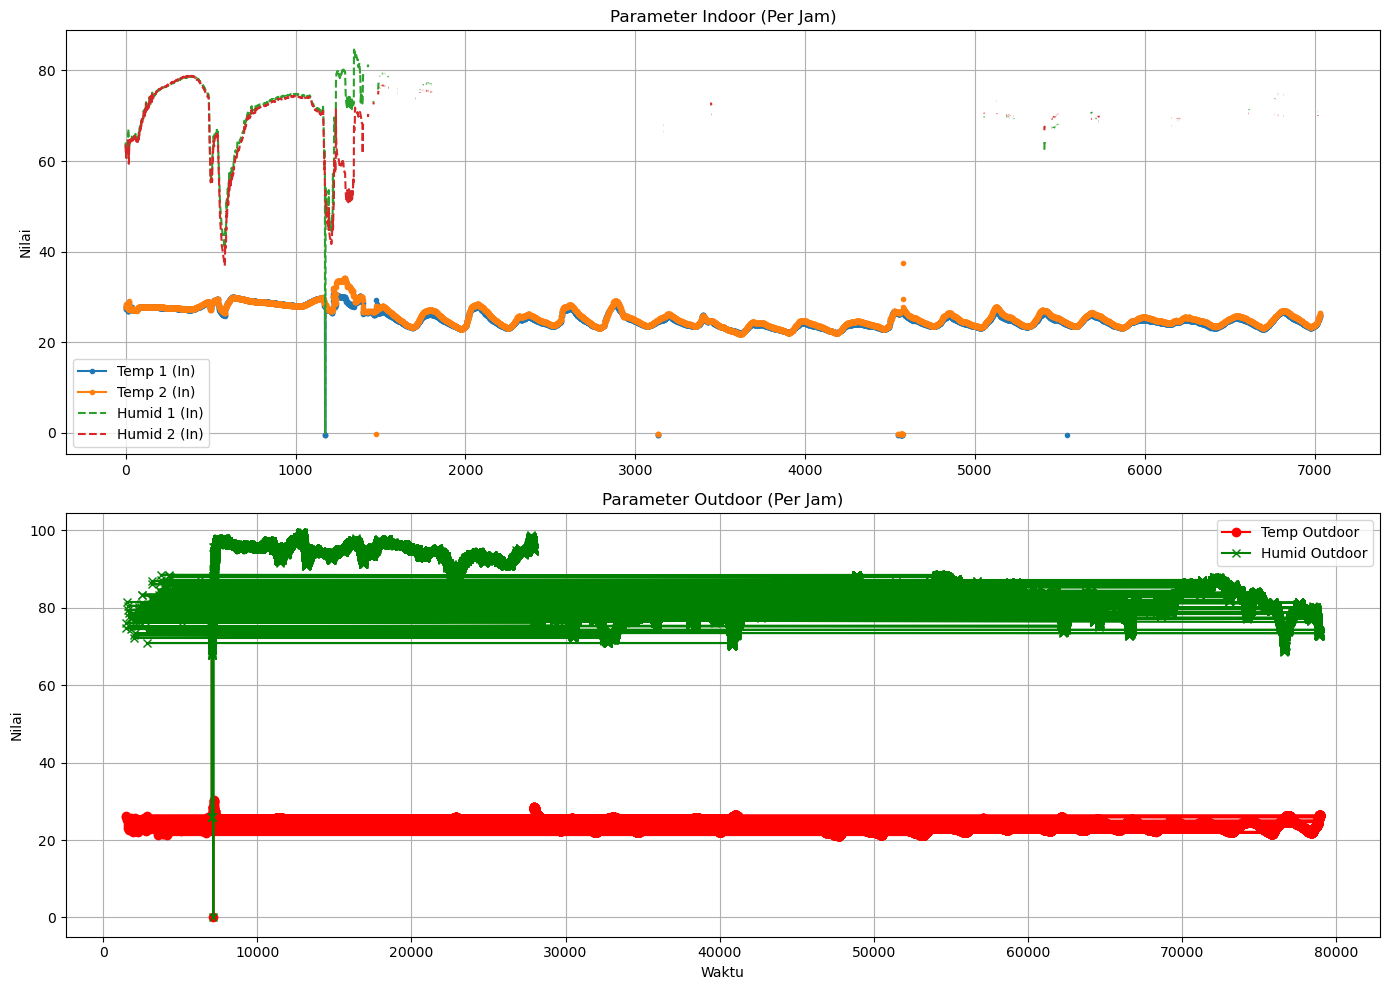

In [3]:
plt.figure(figsize=(14, 10))

plt.subplot(2, 1, 1)
plt.plot(df_merged.index, df_merged['Temp1'], label='Temp 1 (In)', marker='.')
plt.plot(df_merged.index, df_merged['Temp2'], label='Temp 2 (In)', marker='.')
plt.plot(df_merged.index, df_merged['Humid 1'], label='Humid 1 (In)', linestyle='--')
plt.plot(df_merged.index, df_merged['Humid 2'], label='Humid 2 (In)', linestyle='--')
plt.title('Parameter Indoor (Per Jam)')
plt.ylabel('Nilai')
plt.legend()
plt.grid(True)

plt.subplot(2, 1, 2)
plt.plot(df_merged.index, df_merged['Temp outdoor'], color='red', label='Temp Outdoor', marker='o')
plt.plot(df_merged.index, df_merged['Humidity outdoor'], color='green', label='Humid Outdoor', marker='x')
plt.title('Parameter Outdoor (Per Jam)')
plt.ylabel('Nilai')
plt.xlabel('Waktu')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [4]:
df_merged.to_csv('Data_Merger.csv')
print("File 'Data_Merger.csv' berhasil disimpan.")

File 'Data_Merger.csv' berhasil disimpan.


In [5]:
df_merged.set_index('Waktu', inplace=True)

df_hourly = df_merged.resample('H').mean()

df_hourly = df_hourly.dropna(how='all')

print("Data Rata-rata per Jam:")
display(df_hourly.head())

Data Rata-rata per Jam:


,Temp1,Temp2,Humid 1,Humid 2,Baterai,Temp outdoor,Humidity outdoor
Waktu,,,,,,,
2025-11-17 09:00:00+07:00,NaN,NaN,NaN,NaN,NaN,29.497778,69.220000
2025-11-17 15:00:00+07:00,NaN,NaN,NaN,NaN,NaN,26.525000,89.760417
2025-11-17 16:00:00+07:00,NaN,NaN,NaN,NaN,NaN,25.381053,95.668947
2025-11-17 17:00:00+07:00,NaN,NaN,NaN,NaN,NaN,24.518919,97.168018
2025-11-17 18:00:00+07:00,NaN,NaN,NaN,NaN,NaN,24.272889,97.597333


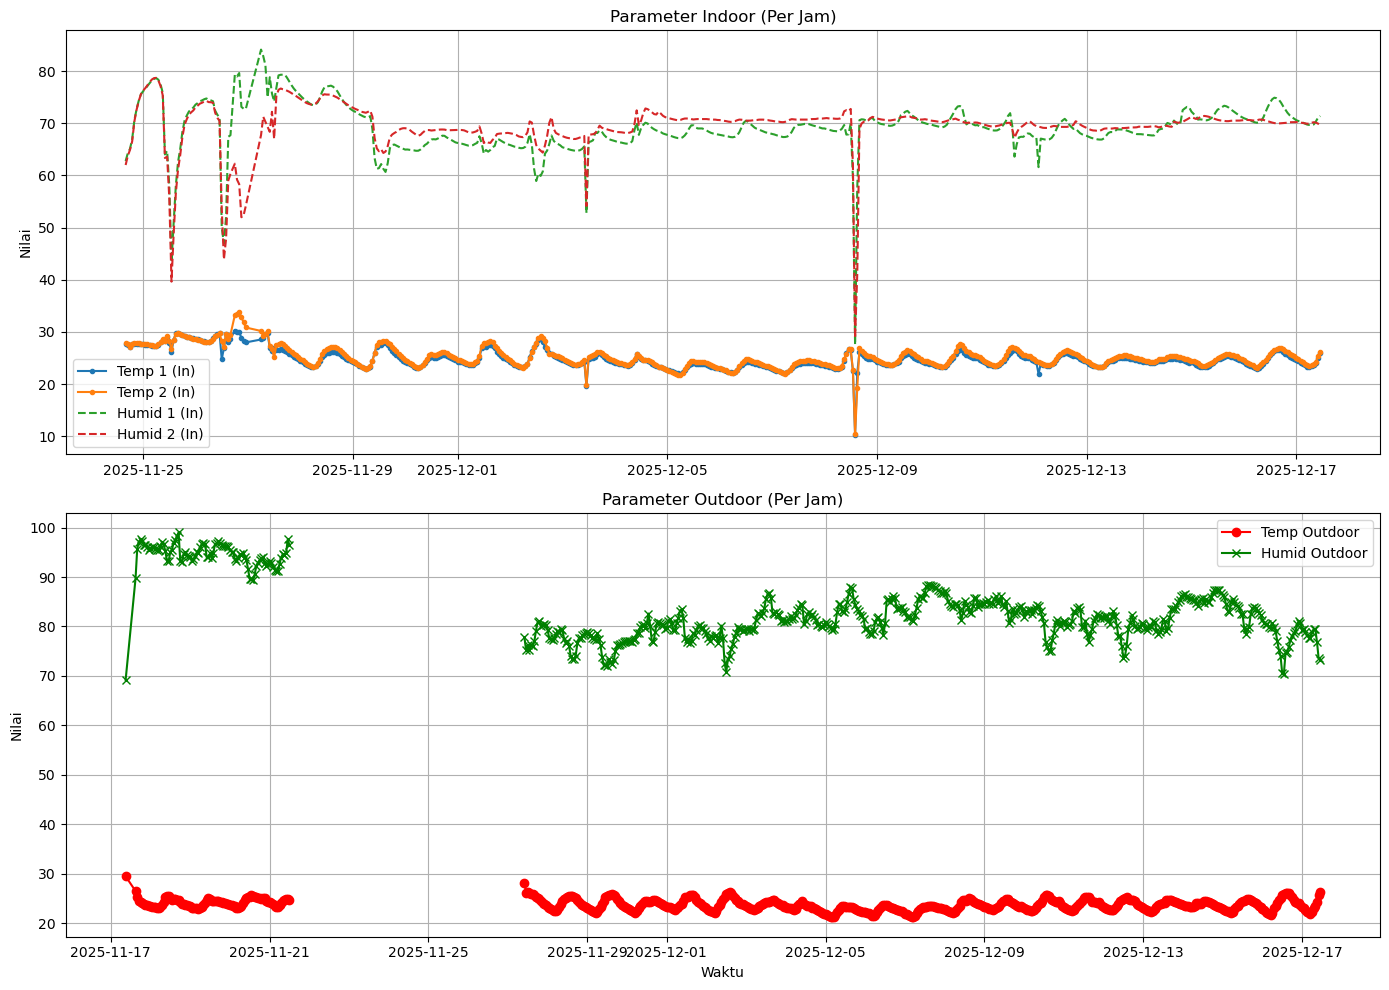

In [6]:
plt.figure(figsize=(14, 10))

plt.subplot(2, 1, 1)
plt.plot(df_hourly.index, df_hourly['Temp1'], label='Temp 1 (In)', marker='.')
plt.plot(df_hourly.index, df_hourly['Temp2'], label='Temp 2 (In)', marker='.')
plt.plot(df_hourly.index, df_hourly['Humid 1'], label='Humid 1 (In)', linestyle='--')
plt.plot(df_hourly.index, df_hourly['Humid 2'], label='Humid 2 (In)', linestyle='--')
plt.title('Parameter Indoor (Per Jam)')
plt.ylabel('Nilai')
plt.legend()
plt.grid(True)

plt.subplot(2, 1, 2)
plt.plot(df_hourly.index, df_hourly['Temp outdoor'], color='red', label='Temp Outdoor', marker='o')
plt.plot(df_hourly.index, df_hourly['Humidity outdoor'], color='green', label='Humid Outdoor', marker='x')
plt.title('Parameter Outdoor (Per Jam)')
plt.ylabel('Nilai')
plt.xlabel('Waktu')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [7]:
df_hourly.to_csv('Data_Hourly_Original.csv')
print("File 'Data_Hourly_Original.csv' berhasil disimpan.")

File 'Data_Hourly_Original.csv' berhasil disimpan.


In [8]:
def clean_outliers(df, column, min_val, max_val):
    df_cleaned = df.copy()
    
    outliers = (df_cleaned[column] < min_val) | (df_cleaned[column] > max_val)
    
    df_cleaned.loc[outliers, column] = df_cleaned[column].mean()
    
    print(f"Kolom {column}: {outliers.sum()} data outlier diperbaiki.")
    return df_cleaned

df_cleaned = df_hourly.copy()

df_cleaned = clean_outliers(df_cleaned, 'Temp1', 15, 45)
df_cleaned = clean_outliers(df_cleaned, 'Temp2', 15, 45)
df_cleaned = clean_outliers(df_cleaned, 'Temp outdoor', 15, 50)

df_cleaned = clean_outliers(df_cleaned, 'Humid 1', 10, 100)
df_cleaned = clean_outliers(df_cleaned, 'Humid 2', 10, 100)
df_cleaned = clean_outliers(df_cleaned, 'Humidity outdoor', 10, 100)

print("\nProses pembersihan outlier selesai.")

Kolom Temp1: 1 data outlier diperbaiki.
Kolom Temp2: 1 data outlier diperbaiki.
Kolom Temp outdoor: 0 data outlier diperbaiki.
Kolom Humid 1: 0 data outlier diperbaiki.
Kolom Humid 2: 0 data outlier diperbaiki.
Kolom Humidity outdoor: 0 data outlier diperbaiki.

Proses pembersihan outlier selesai.


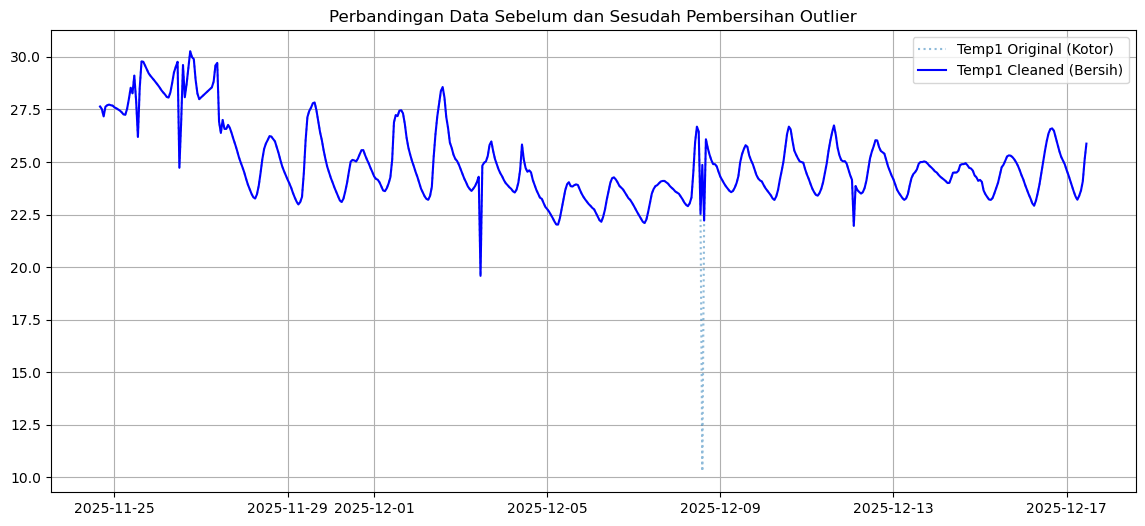

In [9]:
plt.figure(figsize=(14, 6))

plt.plot(df_hourly.index, df_hourly['Temp1'], label='Temp1 Original (Kotor)', alpha=0.5, linestyle=':')
plt.plot(df_cleaned.index, df_cleaned['Temp1'], label='Temp1 Cleaned (Bersih)', color='blue')

plt.title('Perbandingan Data Sebelum dan Sesudah Pembersihan Outlier')
plt.legend()
plt.grid(True)
plt.show()

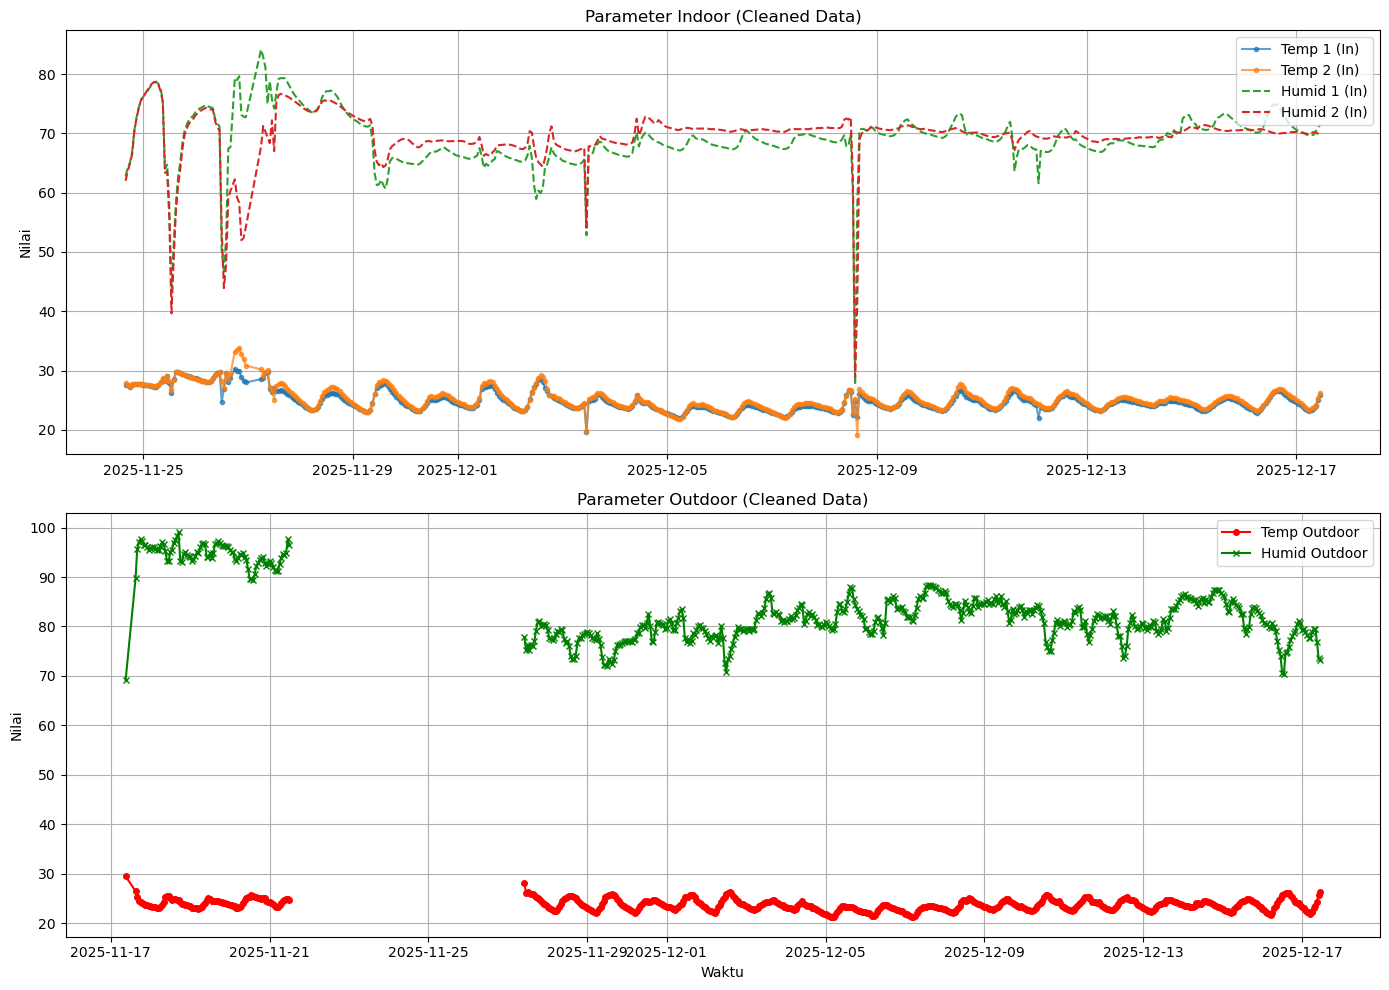

In [10]:
import matplotlib.pyplot as plt


plt.figure(figsize=(14, 10))

plt.subplot(2, 1, 1)
plt.plot(df_cleaned.index, df_cleaned['Temp1'], label='Temp 1 (In)', marker='.', alpha=0.7)
plt.plot(df_cleaned.index, df_cleaned['Temp2'], label='Temp 2 (In)', marker='.', alpha=0.7)
plt.plot(df_cleaned.index, df_cleaned['Humid 1'], label='Humid 1 (In)', linestyle='--')
plt.plot(df_cleaned.index, df_cleaned['Humid 2'], label='Humid 2 (In)', linestyle='--')
plt.title('Parameter Indoor (Cleaned Data)')
plt.ylabel('Nilai')
plt.legend(loc='upper right')
plt.grid(True)

plt.subplot(2, 1, 2)
plt.plot(df_cleaned.index, df_cleaned['Temp outdoor'], color='red', label='Temp Outdoor', marker='o', markersize=4)
plt.plot(df_cleaned.index, df_cleaned['Humidity outdoor'], color='green', label='Humid Outdoor', marker='x', markersize=4)
plt.title('Parameter Outdoor (Cleaned Data)')
plt.ylabel('Nilai')
plt.xlabel('Waktu')
plt.legend(loc='upper right')
plt.grid(True)

plt.tight_layout()
plt.show()

In [11]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

fig = make_subplots(
    rows=2, cols=1, 
    shared_xaxes=True, 
    vertical_spacing=0.1, 
    subplot_titles=("Indoor Monitor", "Outdoor Monitor")
)

fig.add_trace(go.Scatter(x=df_cleaned.index, y=df_cleaned['Temp1'], name='Temp 1 (In)', mode='lines'), row=1, col=1)
fig.add_trace(go.Scatter(x=df_cleaned.index, y=df_cleaned['Temp2'], name='Temp 2 (In)', mode='lines'), row=1, col=1)
fig.add_trace(go.Scatter(x=df_cleaned.index, y=df_cleaned['Humid 1'], name='Humid 1 (In)', line=dict(dash='dot')), row=1, col=1)
fig.add_trace(go.Scatter(x=df_cleaned.index, y=df_cleaned['Humid 2'], name='Humid 2 (In)', line=dict(dash='dot')), row=1, col=1)

fig.add_trace(go.Scatter(x=df_cleaned.index, y=df_cleaned['Temp outdoor'], name='Temp Out', line=dict(color='red')), row=2, col=1)
fig.add_trace(go.Scatter(x=df_cleaned.index, y=df_cleaned['Humidity outdoor'], name='Humid Out', line=dict(color='green')), row=2, col=1)

fig.update_layout(
    height=800, 
    title_text="Grafik Interaktif Indoor vs Outdoor (Fixed)",
    showlegend=True,
    xaxis=dict(
        rangeslider=dict(visible=False), 
        type="date"
    ),
    xaxis2=dict(
        rangeslider=dict(visible=True),  
        type="date"
    )
)

fig.update_xaxes(
    rangeselector=dict(
        buttons=list([
            dict(count=7, label="1 Week", step="day", stepmode="backward"),
            dict(count=1, label="1 Month", step="month", stepmode="backward"),
            dict(step="all", label="All Data")
        ])
    ),
    row=2, col=1 
)

fig.show()

In [12]:
import pandas as pd
import numpy as np

# 1. Ambil Zona Waktu
tz_info = df_cleaned.index.tz

# 2. SET WAKTU BARU (Berdasarkan Screenshot Anda: 15:00)
# Kita ambil range aman dari jam 12 siang sampai jam 6 sore untuk menutup jurang
start_fix_str = '2025-12-08 12:00:00'
end_fix_str   = '2025-12-08 18:00:00'

# Localize waktu agar cocok dengan index DataFrame
start_fix = pd.Timestamp(start_fix_str).tz_localize(tz_info)
end_fix   = pd.Timestamp(end_fix_str).tz_localize(tz_info)

print(f"Memperbaiki range: {start_fix} s/d {end_fix}")

# 3. Buat Masking
mask = (df_cleaned.index >= start_fix) & (df_cleaned.index <= end_fix)

if mask.sum() > 0:
    print(f"Ditemukan {mask.sum()} data yang akan diperbaiki.")
    
    cols_to_fix = ['Humid 1', 'Humid 2'] 
    
    # Simpan nilai lama untuk bukti
    print("Nilai LAMA:")
    print(df_cleaned.loc[mask, cols_to_fix])

    # Hapus jadi NaN
    df_cleaned.loc[mask, cols_to_fix] = np.nan

    # Interpolasi
    df_cleaned[cols_to_fix] = df_cleaned[cols_to_fix].interpolate(method='time', limit_direction='both')

    # Tampilkan nilai baru
    print("\nNilai BARU (Sudah Rata):")
    print(df_cleaned.loc[mask, cols_to_fix])
    
    print("\nPerbaikan Selesai.")
else:
    print("Data tidak ditemukan! Cek kembali tanggalnya.")

Memperbaiki range: 2025-12-08 12:00:00+07:00 s/d 2025-12-08 18:00:00+07:00
Ditemukan 7 data yang akan diperbaiki.
Nilai LAMA:
                             Humid 1    Humid 2
Waktu                                          
2025-12-08 12:00:00+07:00  69.975000  72.741668
2025-12-08 13:00:00+07:00  59.600000  62.171431
2025-12-08 14:00:00+07:00  27.546667  28.853335
2025-12-08 15:00:00+07:00  57.616667  41.166668
2025-12-08 16:00:00+07:00  70.581818  68.918185
2025-12-08 17:00:00+07:00  70.758333  69.950003
2025-12-08 18:00:00+07:00  70.708333  70.291667

Nilai BARU (Sudah Rata):
                             Humid 1    Humid 2
Waktu                                          
2025-12-08 12:00:00+07:00  68.203958  72.071254
2025-12-08 13:00:00+07:00  68.537917  71.832503
2025-12-08 14:00:00+07:00  68.871875  71.593753
2025-12-08 15:00:00+07:00  69.205833  71.355002
2025-12-08 16:00:00+07:00  69.539792  71.116252
2025-12-08 17:00:00+07:00  69.873750  70.877501
2025-12-08 18:00:00+07:00  70.20

In [13]:
# Pastikan index menggunakan datetime
# Kita filter khusus tanggal 8 Desember 2025
check_date = '2025-12-08'

print(f"--- Data Lengkap {check_date} ---")
# Kita ambil data pada tanggal tersebut
day_data = df_cleaned[df_cleaned.index.astype(str).str.contains(check_date)]

# Tampilkan kolom Humidity saja agar mudah dilihat
display(day_data[['Humid 1', 'Humid 2']])

--- Data Lengkap 2025-12-08 ---


,Humid 1,Humid 2
Waktu,,
2025-12-08 00:00:00+07:00,69.000000,70.944444
2025-12-08 01:00:00+07:00,68.883333,70.991667
2025-12-08 02:00:00+07:00,68.750000,70.925000
2025-12-08 03:00:00+07:00,68.650000,70.900000
2025-12-08 04:00:00+07:00,68.525000,70.900000
2025-12-08 05:00:00+07:00,68.491667,70.858333
2025-12-08 06:00:00+07:00,68.436364,70.845455
2025-12-08 07:00:00+07:00,68.591667,70.891667
2025-12-08 08:00:00+07:00,68.966667,71.125004


In [14]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Membuat Subplots (2 Baris, 1 Kolom)
fig = make_subplots(
    rows=2, cols=1, 
    shared_xaxes=True, 
    vertical_spacing=0.1, # Jarak antar grafik
    subplot_titles=("Indoor Monitor", "Outdoor Monitor")
)

# --- INDOOR TRACES (Baris 1) ---
fig.add_trace(go.Scatter(x=df_cleaned.index, y=df_cleaned['Temp1'], name='Temp 1 (In)', mode='lines'), row=1, col=1)
fig.add_trace(go.Scatter(x=df_cleaned.index, y=df_cleaned['Temp2'], name='Temp 2 (In)', mode='lines'), row=1, col=1)
fig.add_trace(go.Scatter(x=df_cleaned.index, y=df_cleaned['Humid 1'], name='Humid 1 (In)', line=dict(dash='dot')), row=1, col=1)
fig.add_trace(go.Scatter(x=df_cleaned.index, y=df_cleaned['Humid 2'], name='Humid 2 (In)', line=dict(dash='dot')), row=1, col=1)

# --- OUTDOOR TRACES (Baris 2) ---
fig.add_trace(go.Scatter(x=df_cleaned.index, y=df_cleaned['Temp outdoor'], name='Temp Out', line=dict(color='red')), row=2, col=1)
fig.add_trace(go.Scatter(x=df_cleaned.index, y=df_cleaned['Humidity outdoor'], name='Humid Out', line=dict(color='green')), row=2, col=1)

# --- UPDATE LAYOUT & SLIDER POSITION ---
fig.update_layout(
    height=800, 
    title_text="Grafik Interaktif Indoor vs Outdoor (Fixed)",
    showlegend=True,
    # Konfigurasi Sumbu X Atas (Tanpa Slider)
    xaxis=dict(
        rangeslider=dict(visible=False), # Pastikan slider MATI di grafik atas
        type="date"
    ),
    # Konfigurasi Sumbu X Bawah (Dengan Slider)
    xaxis2=dict(
        rangeslider=dict(visible=True),  # Slider HIDUP di grafik bawah
        type="date"
    )
)

# Tambahkan tombol preset waktu (1 Week, 1 Month)
# Kita tempelkan ke layout umum agar mengontrol seluruh sumbu x
fig.update_xaxes(
    rangeselector=dict(
        buttons=list([
            dict(count=7, label="1 Week", step="day", stepmode="backward"),
            dict(count=1, label="1 Month", step="month", stepmode="backward"),
            dict(step="all", label="All Data")
        ])
    ),
    row=2, col=1 # Tempelkan tombol ini di baris ke-2 (bawah) dekat slider
)

fig.show()

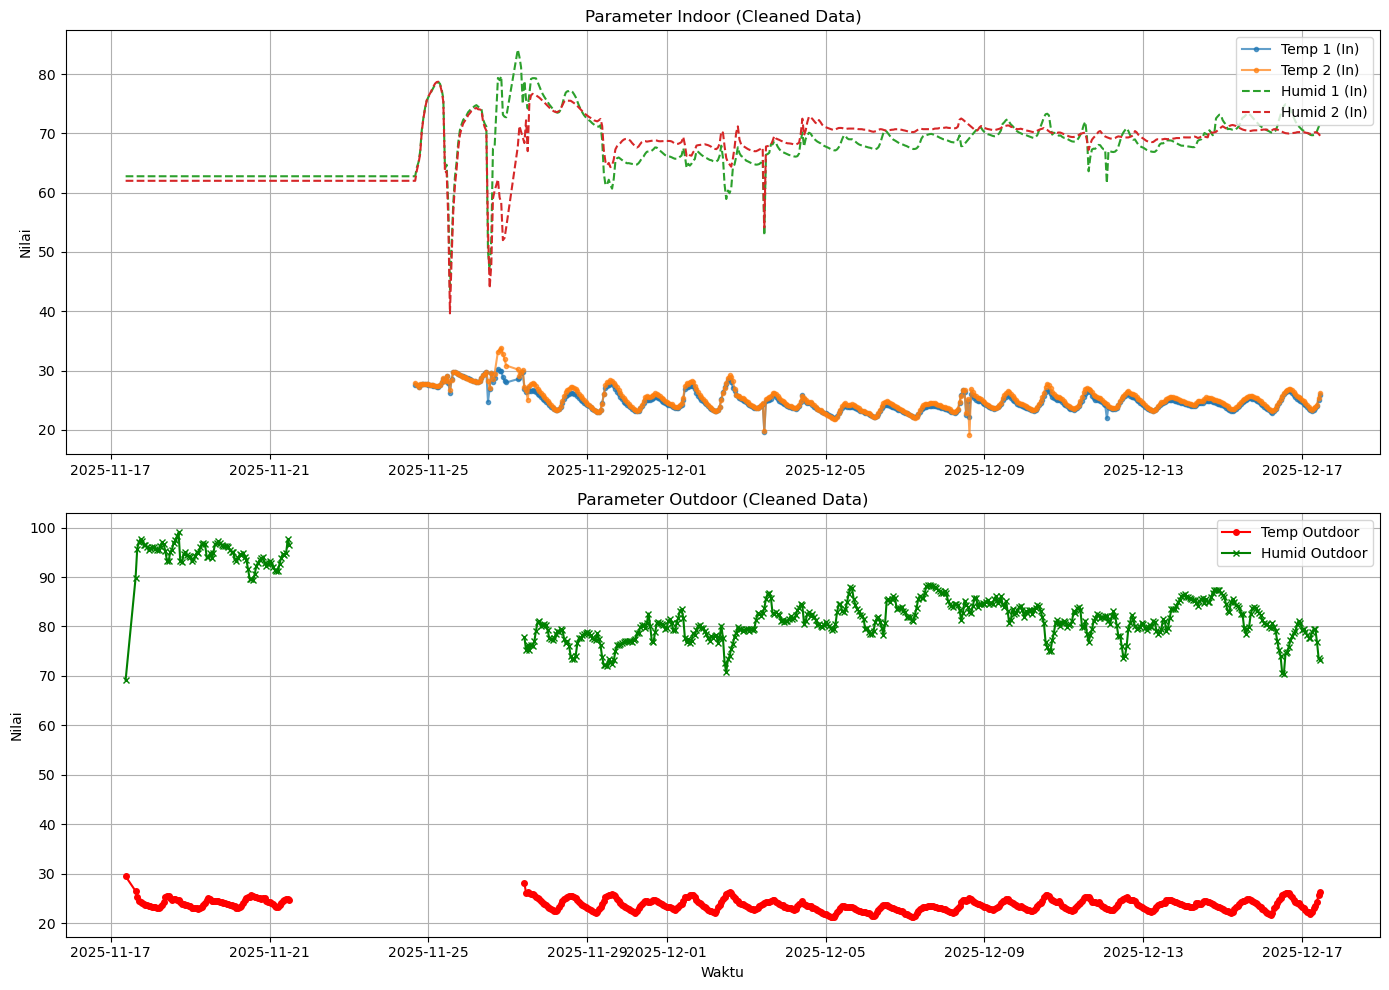

In [15]:
import matplotlib.pyplot as plt

# Pastikan index sudah dalam format datetime (jika belum)
# df_cleaned.index = pd.to_datetime(df_cleaned.index)

# Set ukuran grafik
plt.figure(figsize=(14, 10))

# Plot 1: Indoor Parameters (Menggunakan df_cleaned)
plt.subplot(2, 1, 1)
plt.plot(df_cleaned.index, df_cleaned['Temp1'], label='Temp 1 (In)', marker='.', alpha=0.7)
plt.plot(df_cleaned.index, df_cleaned['Temp2'], label='Temp 2 (In)', marker='.', alpha=0.7)
plt.plot(df_cleaned.index, df_cleaned['Humid 1'], label='Humid 1 (In)', linestyle='--')
plt.plot(df_cleaned.index, df_cleaned['Humid 2'], label='Humid 2 (In)', linestyle='--')
plt.title('Parameter Indoor (Cleaned Data)')
plt.ylabel('Nilai')
plt.legend(loc='upper right')
plt.grid(True)

# Plot 2: Outdoor Parameters (Menggunakan df_cleaned)
plt.subplot(2, 1, 2)
plt.plot(df_cleaned.index, df_cleaned['Temp outdoor'], color='red', label='Temp Outdoor', marker='o', markersize=4)
plt.plot(df_cleaned.index, df_cleaned['Humidity outdoor'], color='green', label='Humid Outdoor', marker='x', markersize=4)
plt.title('Parameter Outdoor (Cleaned Data)')
plt.ylabel('Nilai')
plt.xlabel('Waktu')
plt.legend(loc='upper right')
plt.grid(True)

plt.tight_layout()
plt.show()

In [16]:
df_cleaned.to_csv('Data_Hourly_Cleaned.csv')
print("File 'Data_Hourly_Cleaned.csv' berhasil disimpan.")

File 'Data_Hourly_Cleaned.csv' berhasil disimpan.
